<a href="https://colab.research.google.com/github/wookgom/2026-1_CV/blob/main/26-1_CV_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV HW3 - 손실 함수, 활성화 함수, 최적화 알고리즘 비교 실험

- 런타임 환경 :  python 3, t4 gpu 사용

이 노트북은 PyTorch 직접 학습 루프(`for epoch in range(...)`)를 사용해 다음 세 가지 요소가 학습 결과에 미치는 영향을 정량적으로 비교한다.

- **실험 A:** CrossEntropy Loss vs MSE Loss(with softmax)
- **실험 B:** ReLU vs LeakyReLU vs Sigmoid
- **실험 C:** SGD vs SGD+Momentum vs Adam, learning rate `{0.1, 0.01, 0.001}`

실험 A/C는 `sklearn`의 `Digits Dataset`, 실험 B는 `make_moons`를 사용했다. 모든 평가 구간은 `model.eval()`과 `with torch.no_grad()`를 사용하였다.



In [1]:
# =============================================================
# 공통 설정 셀
# - 세 실험(A/B/C)에서 공통으로 사용할 라이브러리, 모델, 데이터 로더,
#   평가 함수, 재현성 설정을 한 번에 정의한다.
# - 실험 조건을 고정해야 손실 함수/활성화 함수/optimizer의 영향만 분리해서 비교할 수 있다.
# =============================================================
import random
import warnings

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# 경고 메시지는 보고서용 출력이 지저분해지는 것을 막기 위해 숨긴다.
warnings.filterwarnings("ignore")


def set_korean_matplotlib_font():
    # 한국어 폰트 꺠짐 방지
    candidate_fonts = [
        "AppleGothic",
        "Arial Unicode MS",
        "NanumGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
        "Malgun Gothic",
    ]
    installed_fonts = {font.name for font in fm.fontManager.ttflist}
    for font_name in candidate_fonts:
        if font_name in installed_fonts:
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_name

    plt.rcParams["axes.unicode_minus"] = False
    return None


# 그래프 시각화 전에 한글 폰트를 먼저 적용한다.
KOREAN_FONT = set_korean_matplotlib_font()

#gpu 사용 우선
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=42):
    # 재현성 확보: Python random, NumPy, PyTorch seed를 모두 고정한다.
    # 같은 실험 조건에서 동일한 결과가 나오도록 DataLoader generator에도 seed를 사용한다.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def display_table(df, title=None):
    # Jupyter/Colab에서는 display()로 표를 깔끔하게 보여주고,
    # 일반 Python 환경에서는 문자열 표로 출력한다.
    if title:
        print(f"\n{title}")
    try:
        from IPython.display import display

        display(df)
    except Exception:
        print(df.to_string(index=False))


def get_digits_data(test_size=0.25, seed=42):
    # 실험 A/C 데이터셋: sklearn Digits Dataset
    # 8x8 흑백 숫자 이미지이므로 각 sample을 64차원 벡터로 사용한다.
    # 픽셀값은 0~16 범위라 16으로 나누어 0~1 범위로 정규화한다.
    X, y = load_digits(return_X_y=True)
    X = (X.astype("float32") / 16.0)
    y = y.astype("int64")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )
    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
        torch.tensor(y_test, dtype=torch.long),
    )


def make_loader(X, y, batch_size=64, shuffle=True, seed=42):
    # DataLoader의 shuffle 순서도 seed를 고정해 실험 재현성을 높인다.
    # batch_size는 학습 안정성과 실행 시간을 고려해 Digits는 64, make_moons는 128을 사용한다.
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        TensorDataset(X, y),
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
    )


class DigitsMLP(nn.Module):
    # 실험 A/C에서 공통으로 사용하는 MLP 구조
    # input 64 -> hidden 256 -> hidden 128 -> output 10
    # 모델 구조를 고정해야 손실 함수 또는 optimizer 변화의 영향만 비교할 수 있다.
    def __init__(self, input_size=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def evaluate_classifier(model, X, y, loss_mode="ce", num_classes=10):
    # 평가 함수: model.eval()과 torch.no_grad()를 사용해 학습 모드와 평가 모드를 분리한다.
    # loss_mode='mse'일 때는 학습 때와 동일하게 softmax + one-hot target으로 loss를 계산한다.
    model.eval()
    X = X.to(DEVICE)
    y = y.to(DEVICE)
    with torch.no_grad():
        logits = model(X)
        if loss_mode == "mse":
            probs = torch.softmax(logits, dim=1)
            targets = F.one_hot(y, num_classes=num_classes).float()
            loss = nn.MSELoss()(probs, targets).item()
        else:
            loss = nn.CrossEntropyLoss()(logits, y).item()
        acc = (logits.argmax(dim=1) == y).float().mean().item()
    return loss, acc


def convergence_epoch(history, metric="test_acc", threshold=0.95):
    # 수렴 속도 지표: accuracy가 기준선(예: 95%, 90%)에 처음 도달한 epoch을 반환한다.
    # 기준선에 도달하지 못하면 None을 반환해 표에서 '미도달'로 표시한다.
    for row in history:
        if row[metric] >= threshold:
            return row["epoch"]
    return None


def stability_label(std_value):
    # 후반부 test loss 표준편차를 이용해 optimizer의 안정성을 간단히 분류한다.
    # 표준편차가 작을수록 후반 진동이 적고 수렴이 안정적이라고 해석한다.
    if std_value < 0.005:
        return "높음"
    if std_value < 0.03:
        return "중간"
    return "낮음"


# 공통 seed와 실행 환경을 출력해 보고서에서 재현성을 확인할 수 있게 한다.
set_seed(42)
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Korean matplotlib font: {KOREAN_FONT or 'not found'}")

PyTorch version: 2.10.0+cu128
Device: cuda
Korean matplotlib font: not found


## 실험 A - 손실 함수 비교

동일한 모델과 optimizer에서 손실 함수만 교체한다.

[실험 A] 손실 함수 비교: CrossEntropy Loss vs MSE Loss(with softmax)
Dataset: sklearn Digits, Model: 64 -> 256 -> 128 -> 10, Optimizer: SGD+Momentum(lr=0.05, momentum=0.9), Epochs: 50

실험 A 정량 비교 표


,손실 함수,최종 정확도(%),최소 Test Loss,95% 도달 epoch,최종 Train Acc(%)
0,CrossEntropy,97.11,0.09347,6,100.00
1,MSE (softmax),90.00,0.01751,미도달,90.87


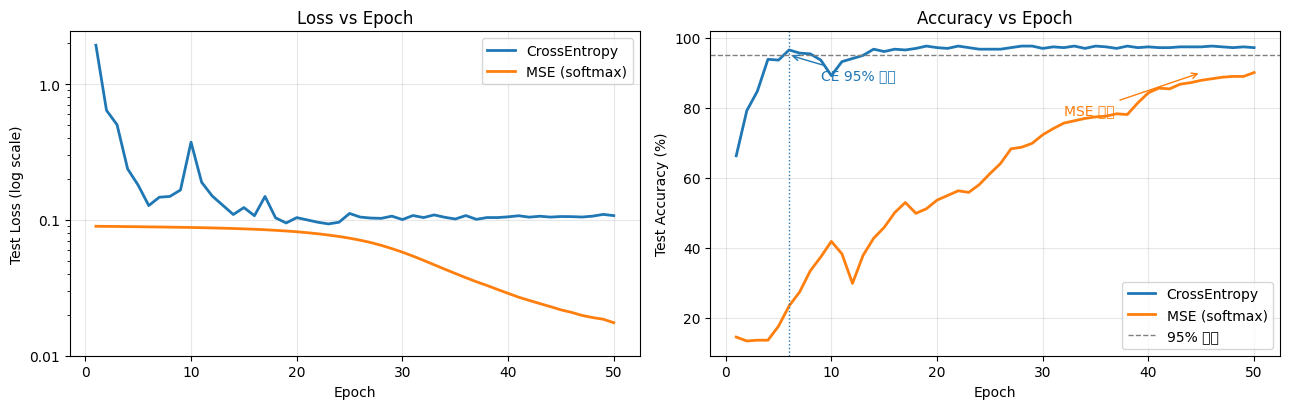


분석 요약
- CrossEntropy는 95% 정확도에 6 epoch 만에 도달했다.
- MSE(with softmax)는 같은 optimizer와 epoch 조건에서 95%에 도달하지 못했다.
- MSE는 softmax 뒤의 확률값에 대해 제곱 오차를 계산하므로, 잘못 분류했더라도 softmax가 포화되면 gradient가 작아져 학습 속도가 느려진다.
- CrossEntropy는 log-softmax 형태의 분류 목적 함수라 정답 클래스 확률을 직접 밀어 올리며, 초기 수렴 속도와 최종 정확도가 더 안정적이다.


In [2]:

print("[실험 A] 손실 함수 비교: CrossEntropy Loss vs MSE Loss(with softmax)")
print("Dataset: sklearn Digits, Model: 64 -> 256 -> 128 -> 10, Optimizer: SGD+Momentum(lr=0.05, momentum=0.9), Epochs: 50")

# 데이터셋: sklearn Digits Dataset 사용
# 8x8 흑백 숫자 이미지, 10개 클래스이며 다운로드 없이 재현 가능하다.
X_train, X_test, y_train, y_test = get_digits_data(seed=42)
train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True, seed=42)
# train_loader는 두 loss 조건에서 동일하게 재사용한다.
# 이렇게 해야 batch 구성 차이가 아니라 loss 함수 차이에 의한 결과만 비교할 수 있다.


def train_loss_experiment(loss_mode, epochs=50, seed=101):
    # loss_mode='ce' 또는 'mse'를 받아 같은 실험 함수를 반복 사용한다.
    # seed를 조건마다 다시 고정하여 두 모델이 같은 초기 weight에서 시작하도록 한다.
    set_seed(seed)
    model = DigitsMLP().to(DEVICE)
    # 동일한 네트워크와 optimizer 조건에서 손실 함수만 바꿔 loss의 영향을 분리한다.
    if loss_mode == "ce":
        # CrossEntropyLoss는 raw logits를 입력받고 내부적으로 log-softmax를 포함한다.
        loss_fn = nn.CrossEntropyLoss()
    else:
        # MSELoss는 softmax 확률과 one-hot label 사이의 제곱 오차를 계산한다.
        loss_fn = nn.MSELoss()

    # 두 loss 모두 SGD+Momentum(lr=0.05, momentum=0.9)으로 고정한다.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    history = []

    # 직접 작성한 epoch loop: 과제 조건에 맞게 trainer API 없이 학습 과정을 명시한다.
    for epoch in range(1, epochs + 1):
        model.train()
        # epoch 단위 train loss/accuracy를 누적해 학습 곡선과 정량 표에 사용한다.
        train_loss_sum = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            # Colab GPU 사용 시 입력과 label도 model과 같은 DEVICE로 이동해야 한다.
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            # 이전 mini-batch의 gradient가 누적되지 않도록 매 step마다 초기화한다.
            optimizer.zero_grad()
            # logits는 softmax 전의 raw score이다.
            logits = model(inputs)

            if loss_mode == "mse":
                # MSE 조건: 출력 logits에 softmax를 명시적으로 적용한다.
                # softmax가 포화되면 gradient가 작아져 gradient vanishing이 발생하기 쉽다.
                outputs = torch.softmax(logits, dim=1)
                targets = F.one_hot(labels, num_classes=10).float()
                loss = loss_fn(outputs, targets)
            else:
                # CrossEntropy는 logits를 그대로 사용하므로 분류 문제에서 수렴이 빠르고 안정적이다.
                loss = loss_fn(logits, labels)

            # autograd로 gradient를 계산한 뒤 optimizer가 parameter를 갱신한다.
            loss.backward()
            optimizer.step()

            # loss는 batch 평균이므로 sample 수를 곱해 epoch 평균을 계산한다.
            # accuracy는 logits의 argmax와 정답 label을 비교한다.
            train_loss_sum += loss.item() * inputs.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += inputs.size(0)

        # 평가 단계에서는 evaluate_classifier 내부에서 model.eval()과 torch.no_grad()가 적용된다.
        test_loss, test_acc = evaluate_classifier(model, X_test, y_test, loss_mode=loss_mode)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss_sum / total,
                "train_acc": correct / total,
                "test_loss": test_loss,
                "test_acc": test_acc,
            }
        )

    return model, pd.DataFrame(history)


# CrossEntropy와 MSE(with softmax)를 같은 함수로 순차 실행하고 결과를 저장한다.
exp_a_results = {}
for loss_name, loss_mode in [("CrossEntropy", "ce"), ("MSE (softmax)", "mse")]:
    model, hist = train_loss_experiment(loss_mode=loss_mode)
    exp_a_results[loss_name] = {"model": model, "history": hist, "loss_mode": loss_mode}

# 정량 비교 표: 최종 정확도, 최소 loss, 기준 정확도 도달 epoch을 한눈에 비교한다.
exp_a_summary_rows = []
for loss_name, result in exp_a_results.items():
    hist = result["history"]
    exp_a_summary_rows.append(
        {
            "손실 함수": loss_name,
            "최종 정확도(%)": round(hist["test_acc"].iloc[-1] * 100, 2),
            "최소 Test Loss": round(hist["test_loss"].min(), 5),
            "95% 도달 epoch": convergence_epoch(hist.to_dict("records"), threshold=0.95) or "미도달",
            "최종 Train Acc(%)": round(hist["train_acc"].iloc[-1] * 100, 2),
        }
    )

exp_a_summary = pd.DataFrame(exp_a_summary_rows)
display_table(exp_a_summary, "실험 A 정량 비교 표")

# 95% 기준선을 표시해 빠른 수렴/미도달 여부를 학습곡선에서 바로 확인한다.
exp_a_ce_95 = convergence_epoch(exp_a_results["CrossEntropy"]["history"].to_dict("records"), threshold=0.95)
exp_a_mse_95 = convergence_epoch(exp_a_results["MSE (softmax)"]["history"].to_dict("records"), threshold=0.95)

# 학습곡선 시각화: Loss vs Epoch, Accuracy vs Epoch
# Accuracy plot에는 95% 기준선과 정체/도달 지점을 표시해 수렴 속도 차이를 명확히 보이게 한다.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for loss_name, result in exp_a_results.items():
    hist = result["history"]
    axes[0].plot(hist["epoch"], hist["test_loss"], label=loss_name, linewidth=2)
    axes[1].plot(hist["epoch"], hist["test_acc"] * 100, label=loss_name, linewidth=2)

axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Loss (log scale)")
axes[0].set_yscale("log")
# log scale의 10^-1 같은 지수 표기가 폰트 환경에 따라 깨질 수 있어 숫자 눈금으로 고정한다.
axes[0].set_yticks([1.0, 0.1, 0.01])
axes[0].set_yticklabels(["1.0", "0.1", "0.01"])
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Accuracy (%)")
axes[1].axhline(95, color="gray", linestyle="--", linewidth=1, label="95% 기준")
if exp_a_ce_95 is not None:
    axes[1].axvline(exp_a_ce_95, color="tab:blue", linestyle=":", linewidth=1)
    axes[1].annotate("CE 95% 도달", xy=(exp_a_ce_95, 95), xytext=(exp_a_ce_95 + 3, 88),
                     arrowprops={"arrowstyle": "->", "color": "tab:blue"}, color="tab:blue")
if exp_a_mse_95 is None:
    axes[1].annotate("MSE 정체", xy=(45, exp_a_results["MSE (softmax)"]["history"]["test_acc"].iloc[-1] * 100),
                     xytext=(32, 78), arrowprops={"arrowstyle": "->", "color": "tab:orange"}, color="tab:orange")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

ce_hist = exp_a_results["CrossEntropy"]["history"]
mse_hist = exp_a_results["MSE (softmax)"]["history"]

print("\n분석 요약")
print(f"- CrossEntropy는 95% 정확도에 {convergence_epoch(ce_hist.to_dict('records'), threshold=0.95)} epoch 만에 도달했다.")
print(f"- MSE(with softmax)는 같은 optimizer와 epoch 조건에서 95%에 {convergence_epoch(mse_hist.to_dict('records'), threshold=0.95) or '도달하지 못했다'}.")
print("- MSE는 softmax 뒤의 확률값에 대해 제곱 오차를 계산하므로, 잘못 분류했더라도 softmax가 포화되면 gradient가 작아져 학습 속도가 느려진다.")
print("- CrossEntropy는 log-softmax 형태의 분류 목적 함수라 정답 클래스 확률을 직접 밀어 올리며, 초기 수렴 속도와 최종 정확도가 더 안정적이다.")

## 실험 B - 활성화 함수 비교

동일한 데이터, 손실 함수, optimizer에서 활성화 함수만 교체하고 dead neuron과 gradient 흐름을 함께 측정한다.

[실험 B] 활성화 함수 비교: ReLU vs LeakyReLU vs Sigmoid
Dataset: make_moons, Model: 2 -> 64 -> 64 -> 64 -> 2, Optimizer: Adam(lr=0.01), Epochs: 300
Dead ReLU 유도를 위해 hidden layer weight std=0.01, bias=-0.05로 초기화했다.

실험 B 정량 비교 표


,활성화 함수,Dead Neuron 비율(%),Layer1 Dead(%),Layer2 Dead(%),Layer3 Dead(%),최종 정확도(%),90% 도달 epoch,첫 hidden grad norm
0,ReLU,96.35,89.06,100.0,100.0,50.0,미도달,0.000e+00
1,LeakyReLU,0.00,0.00,0.0,0.0,92.5,8,5.474e-02
2,Sigmoid,0.00,0.00,0.0,0.0,92.5,26,8.355e-03


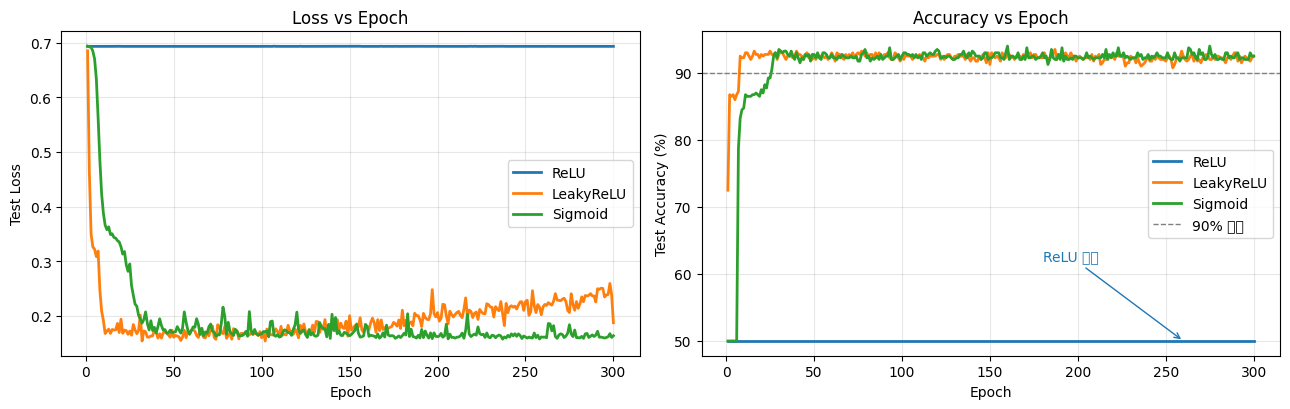

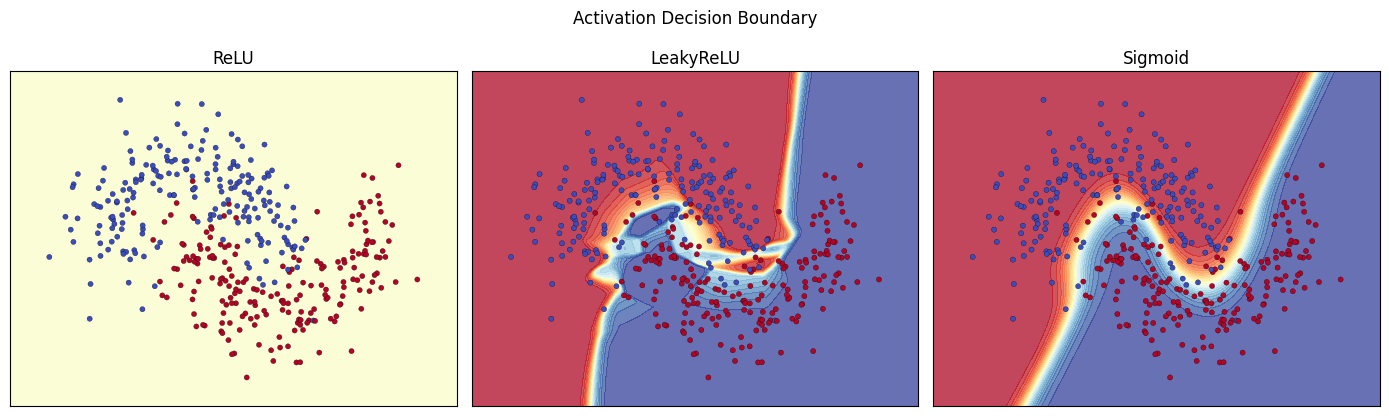

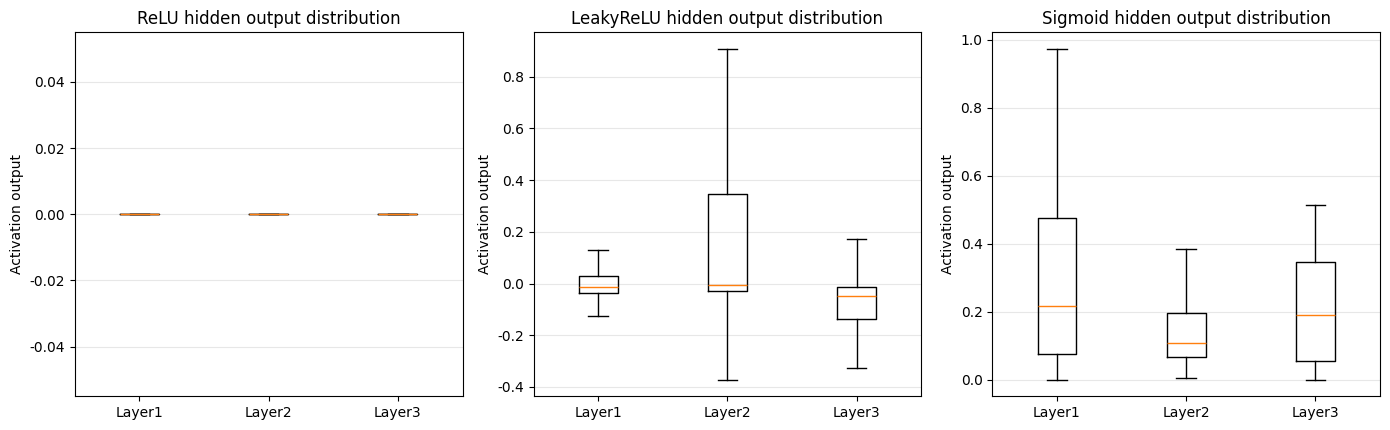

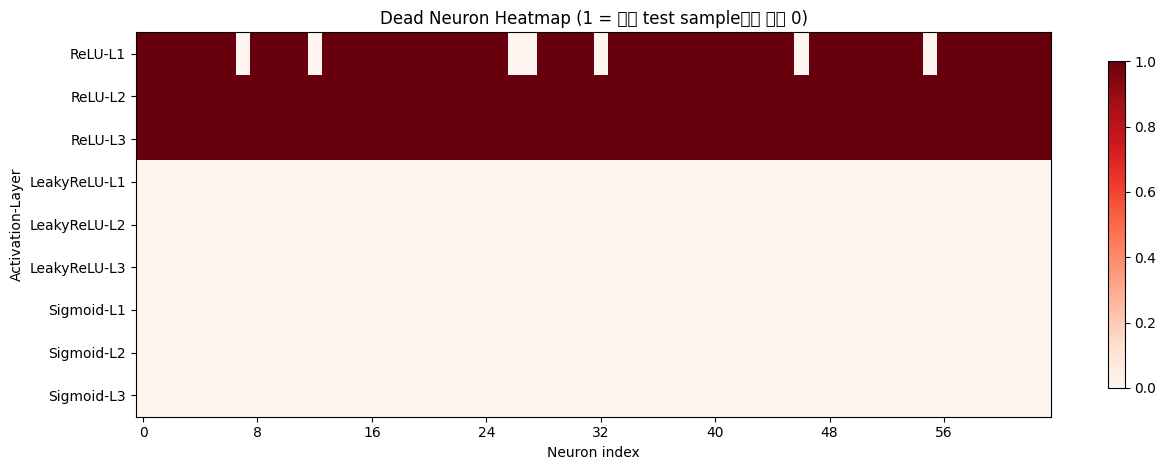

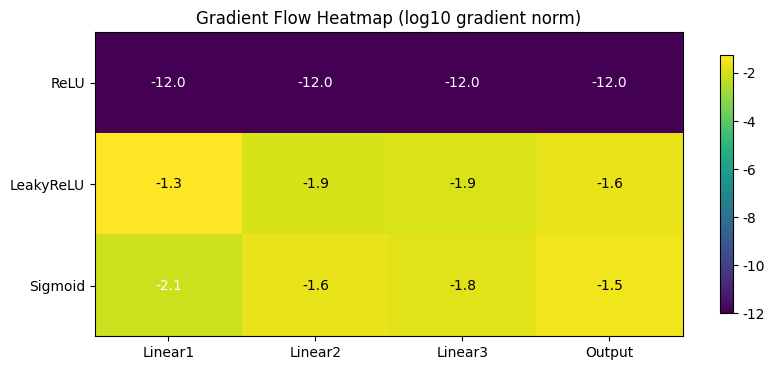


분석 요약
- ReLU는 음수 영역의 gradient가 0이어서, 작은 weight와 음수 bias 초기화 조건에서 Layer2/3가 완전히 죽는 현상이 관찰된다.
- LeakyReLU는 음수 입력에도 작은 기울기를 남기므로 dead neuron 비율이 0%이고 decision boundary가 정상적으로 학습된다.
- Sigmoid는 dead neuron은 만들지 않지만 출력이 좁은 범위로 압축되고 앞쪽 gradient가 작아져 LeakyReLU보다 gradient 흐름이 약하다.


In [3]:

print("[실험 B] 활성화 함수 비교: ReLU vs LeakyReLU vs Sigmoid")
print("Dataset: make_moons, Model: 2 -> 64 -> 64 -> 64 -> 2, Optimizer: Adam(lr=0.01), Epochs: 300")
print("Dead ReLU 유도를 위해 hidden layer weight std=0.01, bias=-0.05로 초기화했다.")

set_seed(42)
# 데이터셋: make_moons 사용
X_np, y_np = make_moons(n_samples=1600, noise=0.25, random_state=42)
# 입력 feature scale이 다르면 activation 분포가 왜곡될 수 있어 표준화한다.
X_np = StandardScaler().fit_transform(X_np).astype("float32")
y_np = y_np.astype("int64")
# train/test split도 random_state를 고정해 재현성을 유지한다.
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.25, stratify=y_np, random_state=42
)
# numpy 배열을 PyTorch tensor로 변환한다. 실제 GPU 이동은 학습/평가 loop 안에서 수행한다.
X_train_b = torch.tensor(X_train_np, dtype=torch.float32)
X_test_b = torch.tensor(X_test_np, dtype=torch.float32)
y_train_b = torch.tensor(y_train_np, dtype=torch.long)
y_test_b = torch.tensor(y_test_np, dtype=torch.long)
train_loader_b = make_loader(X_train_b, y_train_b, batch_size=128, shuffle=True, seed=42)


# 동일 네트워크(2 -> 64 -> 64 -> 64 -> 2), CrossEntropyLoss, Adam(lr=0.01) 조건에서 활성화 함수만 바꾼다.
class ActivationMLP(nn.Module):
    def __init__(self, activation="relu", hidden_size=64, weight_std=0.01, bias_init=-0.05):
        super().__init__()
        # activation 문자열에 따라 hidden layer에 들어갈 활성화 함수를 선택한다.
        # ReLU는 Dead ReLU를 관찰하기 위한 조건, LeakyReLU는 완화 조건, Sigmoid는 vanishing gradient 비교 조건이다.
        if activation == "relu":
            act_factory = nn.ReLU
        elif activation == "leakyrelu":
            act_factory = lambda: nn.LeakyReLU(negative_slope=0.05)
        elif activation == "sigmoid":
            act_factory = nn.Sigmoid
        else:
            raise ValueError(activation)

        # hidden layer를 ModuleList로 따로 보관하면 각 layer의 activation과 gradient를 쉽게 추적할 수 있다.
        self.hidden_layers = nn.ModuleList(
            [
                nn.Linear(2, hidden_size),
                nn.Linear(hidden_size, hidden_size),
                nn.Linear(hidden_size, hidden_size),
            ]
        )
        self.activations = nn.ModuleList([act_factory(), act_factory(), act_factory()])
        self.output_layer = nn.Linear(hidden_size, 2)

        # Dead ReLU 유도: weight_std=0.01, bias=-0.05로 초기화해 ReLU가 꺼지기 쉬운 조건을 만든다.
        for layer in self.hidden_layers:
            nn.init.normal_(layer.weight, mean=0.0, std=weight_std)
            nn.init.constant_(layer.bias, bias_init)
        nn.init.normal_(self.output_layer.weight, mean=0.0, std=weight_std)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, x, return_activations=False):
        # return_activations=True일 때 hidden layer 출력값을 함께 반환한다.
        # 이 값은 boxplot, Dead ReLU ratio, heatmap 분석에 사용된다.
        hidden_outputs = []
        for layer, activation in zip(self.hidden_layers, self.activations):
            x = activation(layer(x))
            hidden_outputs.append(x)
        logits = self.output_layer(x)
        if return_activations:
            return logits, hidden_outputs
        return logits


def evaluate_activation_model(model):
    # 활성화 함수 실험 전용 평가 함수
    # test set을 DEVICE로 이동한 뒤 no_grad로 loss/accuracy만 계산한다.
    model.eval()
    X = X_test_b.to(DEVICE)
    y = y_test_b.to(DEVICE)
    with torch.no_grad():
        logits = model(X)
        loss = nn.CrossEntropyLoss()(logits, y).item()
        acc = (logits.argmax(dim=1) == y).float().mean().item()
    return loss, acc


def train_activation_experiment(activation, epochs=300, seed=123):
    # activation 조건마다 seed를 다시 고정해 초기화 차이가 아닌 activation 차이를 비교한다.
    set_seed(seed)
    model = ActivationMLP(activation=activation).to(DEVICE)
    # loss와 optimizer는 모든 activation 조건에서 동일하게 고정한다.
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        correct = 0
        total = 0
        # mini-batch 학습을 직접 구현한다.
        for inputs, labels in train_loader_b:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * inputs.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += inputs.size(0)

        test_loss, test_acc = evaluate_activation_model(model)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss_sum / total,
                "train_acc": correct / total,
                "test_loss": test_loss,
                "test_acc": test_acc,
            }
        )
    return model, pd.DataFrame(history)


def activation_diagnostics(model):
    # 학습 후 진단 함수
    # 1) hidden activation 출력 분포
    # 2) Dead neuron 비율
    # 3) layer별 gradient norm
    # 을 계산해 활성화 함수별 학습 실패/성공 원인을 분석한다.
    model.eval()
    with torch.no_grad():
        # Layer별 출력값을 저장해 activation 분포 boxplot과 Dead ReLU heatmap에 사용한다.
        _, hidden_outputs = model(X_test_b.to(DEVICE), return_activations=True)

    dead_masks = []
    dead_ratios = []
    zero_shares = []
    activation_arrays = []
    for hidden in hidden_outputs:
        arr = hidden.detach().cpu()
        # Dead neuron 정의: test sample 전체에서 출력이 항상 0인 neuron
        dead_mask = (arr.abs() < 1e-8).all(dim=0).numpy().astype(float)
        dead_masks.append(dead_mask)
        dead_ratios.append(float(dead_mask.mean()))
        # zero_shares는 전체 activation 값 중 0에 가까운 값의 비율이다.
        # dead_ratios는 neuron 단위로 모든 sample에서 항상 0인지 보는 더 엄격한 지표이다.
        zero_shares.append(float((arr.abs() < 1e-8).float().mean().item()))
        activation_arrays.append(arr.numpy())

    model.train()
    model.zero_grad()
    # gradient 흐름을 측정해 Sigmoid vanishing gradient와 Dead ReLU의 gradient 0 현상을 확인한다.
    logits = model(X_train_b.to(DEVICE))
    loss = nn.CrossEntropyLoss()(logits, y_train_b.to(DEVICE))
    loss.backward()
    grad_norms = [layer.weight.grad.norm().item() for layer in model.hidden_layers]
    grad_norms.append(model.output_layer.weight.grad.norm().item())

    return {
        "dead_masks": dead_masks,
        "dead_ratios": dead_ratios,
        "zero_shares": zero_shares,
        "activation_arrays": activation_arrays,
        "grad_norms": grad_norms,
    }


# activation key와 표/그래프에 표시할 이름을 매핑한다.
activation_names = {
    "relu": "ReLU",
    "leakyrelu": "LeakyReLU",
    "sigmoid": "Sigmoid",
}

# 세 activation을 동일 조건으로 반복 실행한다.
exp_b_results = {}
for activation_key in ["relu", "leakyrelu", "sigmoid"]:
    model, history = train_activation_experiment(activation_key)
    diagnostics = activation_diagnostics(model)
    exp_b_results[activation_names[activation_key]] = {
        "model": model,
        "history": history,
        "diagnostics": diagnostics,
    }

# 정량 비교 표: Dead neuron 비율, 최종 정확도, 수렴 epoch, gradient norm을 함께 비교한다.
exp_b_summary_rows = []
for activation_name, result in exp_b_results.items():
    hist = result["history"]
    diag = result["diagnostics"]
    exp_b_summary_rows.append(
        {
            "활성화 함수": activation_name,
            "Dead Neuron 비율(%)": round(np.mean(diag["dead_ratios"]) * 100, 2),
            "Layer1 Dead(%)": round(diag["dead_ratios"][0] * 100, 2),
            "Layer2 Dead(%)": round(diag["dead_ratios"][1] * 100, 2),
            "Layer3 Dead(%)": round(diag["dead_ratios"][2] * 100, 2),
            "최종 정확도(%)": round(hist["test_acc"].iloc[-1] * 100, 2),
            "90% 도달 epoch": convergence_epoch(hist.to_dict("records"), threshold=0.90) or "미도달",
            "첫 hidden grad norm": f"{diag['grad_norms'][0]:.3e}",
        }
    )

exp_b_summary = pd.DataFrame(exp_b_summary_rows)
display_table(exp_b_summary, "실험 B 정량 비교 표")

# Loss/Accuracy 곡선: ReLU 정체, LeakyReLU 빠른 수렴, Sigmoid 느린 초반 수렴을 비교한다.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for activation_name, result in exp_b_results.items():
    hist = result["history"]
    axes[0].plot(hist["epoch"], hist["test_loss"], label=activation_name, linewidth=2)
    axes[1].plot(hist["epoch"], hist["test_acc"] * 100, label=activation_name, linewidth=2)
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Accuracy (%)")
axes[1].axhline(90, color="gray", linestyle="--", linewidth=1, label="90% 기준")
relu_final_acc = exp_b_results["ReLU"]["history"]["test_acc"].iloc[-1] * 100
axes[1].annotate("ReLU 정체", xy=(260, relu_final_acc), xytext=(180, 62),
                 arrowprops={"arrowstyle": "->", "color": "tab:blue"}, color="tab:blue")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()


def plot_decision_boundary(ax, model, title):
    # 2D 격자 전체에 대해 class 1 확률을 계산해 decision boundary를 그린다.
    # ReLU는 dead neuron 때문에 경계가 거의 형성되지 않고, LeakyReLU/Sigmoid는 비선형 경계를 학습한다.
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 240), np.linspace(y_min, y_max, 240))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(grid.to(DEVICE)), dim=1)[:, 1].reshape(xx.shape).cpu().numpy()
    ax.contourf(xx, yy, probs, levels=30, cmap="RdYlBu", alpha=0.75)
    ax.scatter(X_test_np[:, 0], X_test_np[:, 1], c=y_test_np, cmap="coolwarm", s=14, edgecolor="k", linewidth=0.2)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (activation_name, result) in zip(axes, exp_b_results.items()):
    plot_decision_boundary(ax, result["model"], activation_name)
plt.suptitle("Activation Decision Boundary")
plt.tight_layout()
plt.show()

# Layer별 activation boxplot
# ReLU는 0 출력 집중, Sigmoid는 좁은 출력 범위/포화, LeakyReLU는 음수 영역 유지 여부를 확인한다.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=False)
for ax, (activation_name, result) in zip(axes, exp_b_results.items()):
    arrays = result["diagnostics"]["activation_arrays"]
    sampled = [arr.reshape(-1)[::8] for arr in arrays]
    ax.boxplot(sampled, labels=["Layer1", "Layer2", "Layer3"], showfliers=False)
    ax.set_title(f"{activation_name} hidden output distribution")
    ax.set_ylabel("Activation output")
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Dead neuron heatmap
# 1은 해당 neuron이 test sample 전체에서 항상 0을 출력한다는 뜻이다.
# Layer2/Layer3가 모두 1에 가까우면 그 layer는 학습에 거의 기여하지 못한다.
heatmap_rows = []
row_labels = []
for activation_name, result in exp_b_results.items():
    for layer_idx, dead_mask in enumerate(result["diagnostics"]["dead_masks"], start=1):
        heatmap_rows.append(dead_mask)
        row_labels.append(f"{activation_name}-L{layer_idx}")
dead_heatmap = np.vstack(heatmap_rows)

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(dead_heatmap, aspect="auto", cmap="Reds", vmin=0, vmax=1)
ax.set_title("Dead Neuron Heatmap (1 = 전체 test sample에서 출력 0)")
ax.set_xlabel("Neuron index")
ax.set_ylabel("Activation-Layer")
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_xticks(np.arange(0, 64, 8))
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

# Gradient flow heatmap
# log10 gradient norm을 사용해 layer별 gradient 소멸/약화 여부를 비교한다.
grad_rows = []
grad_labels = []
for activation_name, result in exp_b_results.items():
    grad_rows.append(np.log10(np.array(result["diagnostics"]["grad_norms"]) + 1e-12))
    grad_labels.append(activation_name)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
im = ax.imshow(np.vstack(grad_rows), aspect="auto", cmap="viridis")
ax.set_title("Gradient Flow Heatmap (log10 gradient norm)")
ax.set_xticks(np.arange(4))
ax.set_xticklabels(["Linear1", "Linear2", "Linear3", "Output"])
ax.set_yticks(np.arange(len(grad_labels)))
ax.set_yticklabels(grad_labels)
for i, row in enumerate(np.vstack(grad_rows)):
    for j, value in enumerate(row):
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", color="white" if value < -2 else "black")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

print("\n분석 요약")
print("- ReLU는 음수 영역의 gradient가 0이어서, 작은 weight와 음수 bias 초기화 조건에서 Layer2/3가 완전히 죽는 현상이 관찰된다.")
print("- LeakyReLU는 음수 입력에도 작은 기울기를 남기므로 dead neuron 비율이 0%이고 decision boundary가 정상적으로 학습된다.")
print("- Sigmoid는 dead neuron은 만들지 않지만 출력이 좁은 범위로 압축되고 앞쪽 gradient가 작아져 LeakyReLU보다 gradient 흐름이 약하다.")

## 실험 C - 최적화 알고리즘 비교

동일한 모델과 손실 함수에서 optimizer와 learning rate를 바꾸고 ExponentialLR scheduler를 적용한다.

[실험 C] 최적화 알고리즘 비교: SGD, SGD+Momentum, Adam
Dataset: sklearn Digits, Model: 64 -> 256 -> 128 -> 10, Loss: CrossEntropy, Epochs: 35
Learning rates: 0.1, 0.01, 0.001 / ExponentialLR gamma=0.9 적용

실험 C 정량 비교 표


,Optimizer,초기 LR,최종 LR,최종 정확도(%),최소 Test Loss,95% 도달 epoch,후반 Loss 표준편차,안정성
0,SGD,0.100,0.002503,92.44,0.29821,미도달,0.00566,중간
1,SGD,0.010,0.000250,54.22,2.23470,미도달,0.00113,높음
2,SGD,0.001,0.000025,9.33,2.29966,미도달,0.00009,높음
3,SGD+Momentum,0.100,0.002503,98.00,0.08070,6,0.00019,높음
4,SGD+Momentum,0.010,0.000250,91.11,0.33347,미도달,0.00786,중간
5,SGD+Momentum,0.001,0.000025,52.89,2.23824,미도달,0.00110,높음
6,Adam,0.100,0.002503,87.56,0.40666,미도달,0.00347,높음
7,Adam,0.010,0.000250,97.78,0.07779,4,0.00028,높음
8,Adam,0.001,0.000025,96.22,0.13152,10,0.00196,높음


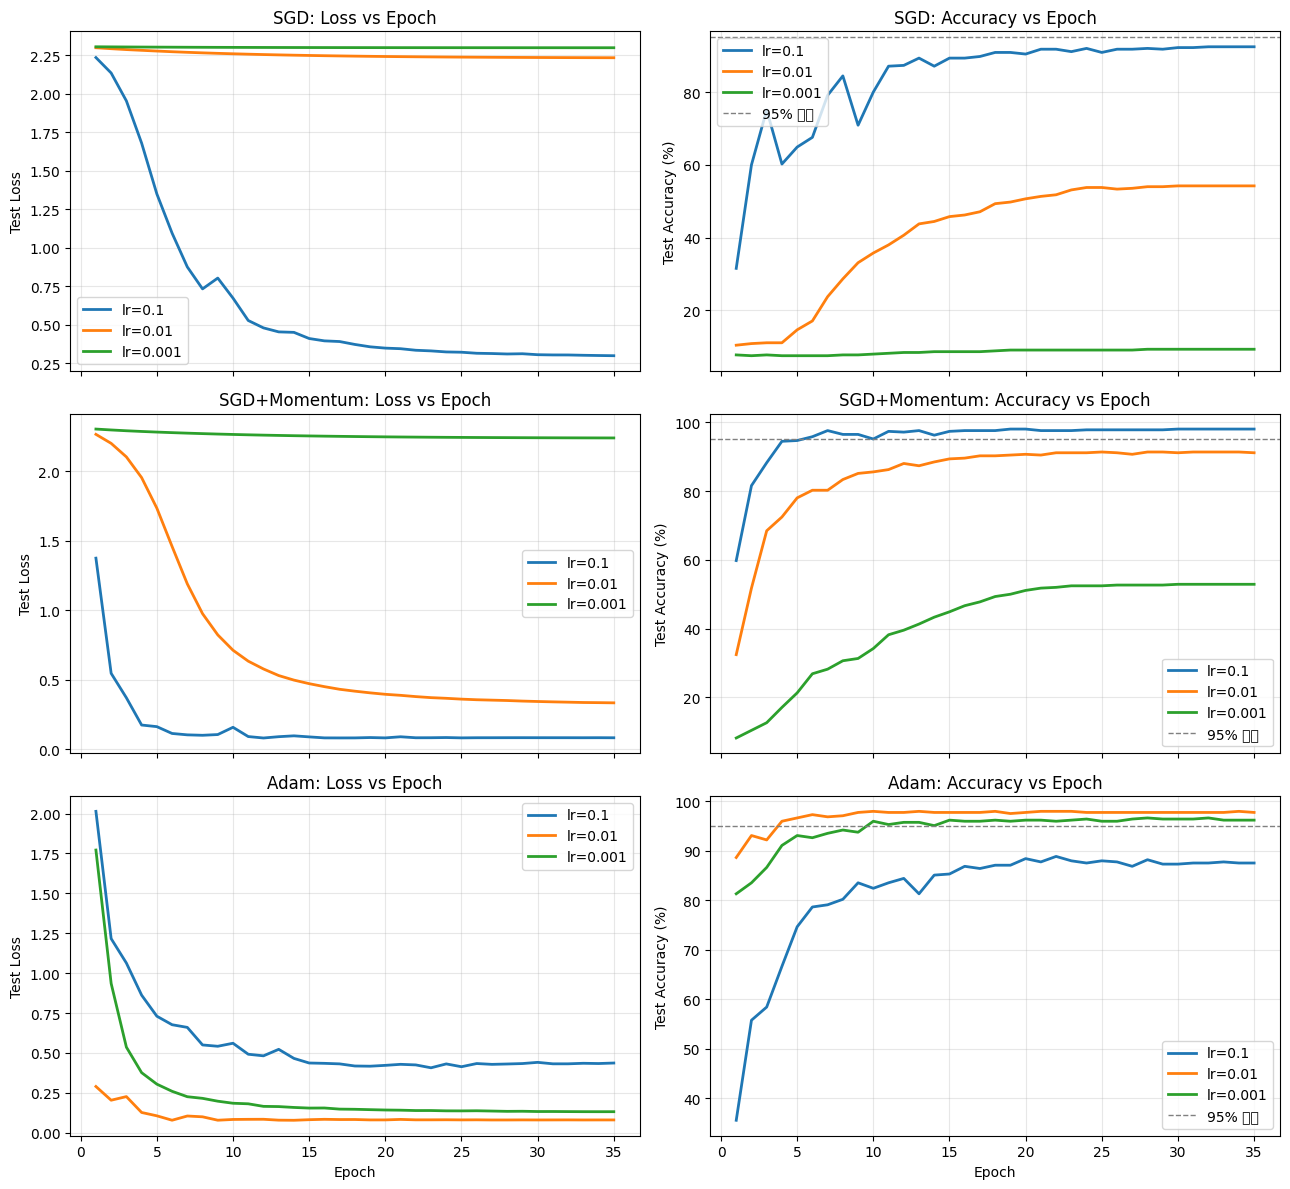

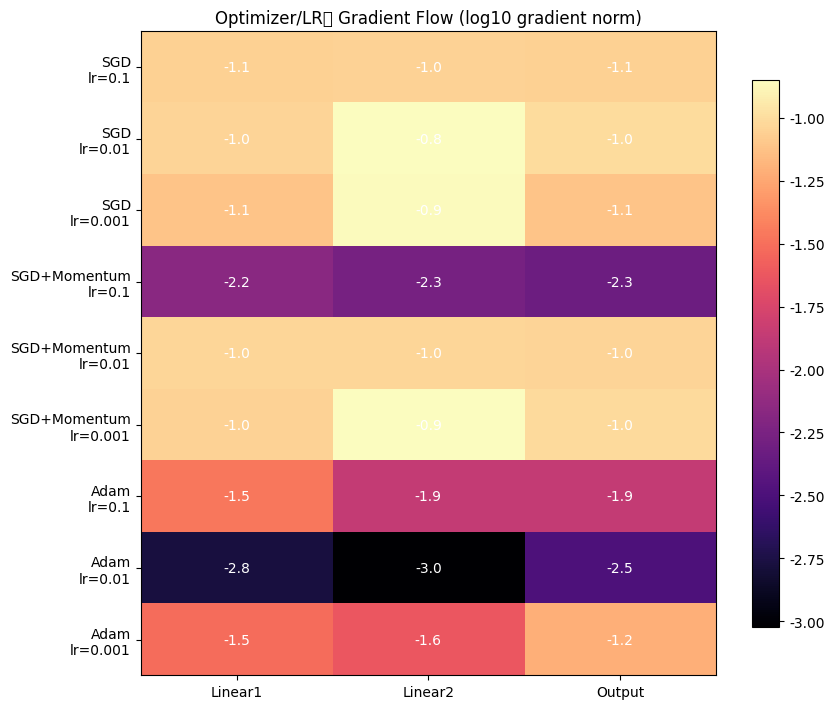


분석 요약
- 가장 높은 최종 정확도는 SGD+Momentum (lr=0.1)의 98.0%였다.
- SGD는 lr=0.001/0.01에서 수렴이 매우 느렸고, lr=0.1에서도 momentum이나 Adam보다 95% 도달이 늦었다.
- SGD+Momentum은 같은 lr에서 SGD보다 빠르게 이동하며, lr=0.1 조건에서 빠른 수렴과 높은 정확도를 보였다.
- Adam은 lr=0.01에서 가장 빠르게 95% 이상으로 수렴했고, lr=0.1에서는 adaptive update가 있어도 큰 step 때문에 안정성이 낮아졌다.
- ExponentialLR(gamma=0.9)는 epoch이 진행될수록 step size를 줄여 후반 loss 진동을 완화하는 효과가 있다.


In [4]:

print("[실험 C] 최적화 알고리즘 비교: SGD, SGD+Momentum, Adam")
print("Dataset: sklearn Digits, Model: 64 -> 256 -> 128 -> 10, Loss: CrossEntropy, Epochs: 35")
print("Learning rates: 0.1, 0.01, 0.001 / ExponentialLR gamma=0.9 적용")

# 실험 A와 동일한 Digits Dataset, 동일 MLP, 동일 CrossEntropyLoss 조건에서 optimizer와 learning rate만 바꾼다.
X_train_c, X_test_c, y_train_c, y_test_c = get_digits_data(seed=42)
train_loader_c = make_loader(X_train_c, y_train_c, batch_size=64, shuffle=True, seed=42)


def train_optimizer_experiment(optimizer_name, lr, epochs=35, seed=202):
    # optimizer/lr 조건마다 seed를 다시 고정해 같은 초기 모델에서 출발한다.
    set_seed(seed)
    # 모델 구조는 실험 A와 동일하게 고정한다.
    model = DigitsMLP().to(DEVICE)
    # 손실 함수는 CrossEntropy로 고정해 optimizer 효과만 분리한다.
    loss_fn = nn.CrossEntropyLoss()

    # SGD, SGD+Momentum, Adam을 수동으로 교체해 수렴 속도와 안정성 차이를 비교한다.
    if optimizer_name == "SGD":
        # SGD: 현재 mini-batch gradient만 사용하므로 단순하지만 learning rate에 민감하다.
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "SGD+Momentum":
        # SGD+Momentum: 이전 gradient 방향을 누적해 관성을 만들고 빠른 수렴을 유도한다.
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        # Adam: gradient의 1차/2차 모멘트를 이용해 parameter별 adaptive learning rate를 적용한다.
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(optimizer_name)

    # Exponential Decay: epoch마다 learning rate를 gamma=0.9배로 줄여 후반 진동을 완화한다.
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    history = []
    final_layer_grad_norms = None

    # 직접 작성한 epoch loop로 optimizer별 학습 곡선을 기록한다.
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        correct = 0
        total = 0

        # 모든 optimizer 조건에서 같은 train_loader를 사용한다.
        for inputs, labels in train_loader_c:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = loss_fn(logits, labels)
            # backward로 gradient를 계산하고, optimizer 종류별 update rule에 따라 parameter를 갱신한다.
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * inputs.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += inputs.size(0)

        # epoch 종료 후 전체 train set 기준으로 gradient를 한 번 더 계산한다.
        # 이 값은 optimizer/LR별 gradient flow heatmap을 만들기 위한 진단용이며, parameter update에는 사용하지 않는다.
        model.train()
        model.zero_grad()
        # layer별 gradient norm으로 gradient 흐름과 학습 안정성을 비교한다.
        logits_full = model(X_train_c.to(DEVICE))
        loss_full = loss_fn(logits_full, y_train_c.to(DEVICE))
        loss_full.backward()
        linear_layers = [module for module in model.net if isinstance(module, nn.Linear)]
        final_layer_grad_norms = [layer.weight.grad.norm().item() for layer in linear_layers]

        # ExponentialLR은 epoch마다 learning rate를 감소시켜 후반부 진동을 줄인다.
        scheduler.step()
        # test set 성능을 기록해 optimizer별 loss/accuracy 곡선을 그린다.
        test_loss, test_acc = evaluate_classifier(model, X_test_c, y_test_c, loss_mode="ce")
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss_sum / total,
                "train_acc": correct / total,
                "test_loss": test_loss,
                "test_acc": test_acc,
                "lr": optimizer.param_groups[0]["lr"],
                "total_grad_norm": float(np.sum(final_layer_grad_norms)),
            }
        )

    return model, pd.DataFrame(history), final_layer_grad_norms


# 학습률 0.1, 0.01, 0.001에 대해 3개 optimizer의 성능을 표와 곡선으로 비교한다.
optimizer_names = ["SGD", "SGD+Momentum", "Adam"]
learning_rates = [0.1, 0.01, 0.001]

exp_c_results = {}
for optimizer_name in optimizer_names:
    for lr in learning_rates:
        model, hist, grad_norms = train_optimizer_experiment(optimizer_name, lr)
        exp_c_results[(optimizer_name, lr)] = {
            "model": model,
            "history": hist,
            "grad_norms": grad_norms,
        }

# 정량 비교 표
# 최종 정확도, 최소 loss, 95% 도달 epoch, 후반 loss 표준편차를 통해
# 수렴 속도와 안정성을 함께 판단한다.
summary_rows = []
for (optimizer_name, lr), result in exp_c_results.items():
    hist = result["history"]
    last10_std = hist["test_loss"].tail(10).std()
    summary_rows.append(
        {
            "Optimizer": optimizer_name,
            "초기 LR": lr,
            "최종 LR": round(hist["lr"].iloc[-1], 6),
            "최종 정확도(%)": round(hist["test_acc"].iloc[-1] * 100, 2),
            "최소 Test Loss": round(hist["test_loss"].min(), 5),
            "95% 도달 epoch": convergence_epoch(hist.to_dict("records"), threshold=0.95) or "미도달",
            "후반 Loss 표준편차": round(last10_std, 5),
            "안정성": stability_label(last10_std),
        }
    )

exp_c_summary = pd.DataFrame(summary_rows)
display_table(exp_c_summary, "실험 C 정량 비교 표")

# optimizer별 Loss/Accuracy 곡선
# 각 행은 optimizer, 각 선은 learning rate를 의미한다.
# 95% 기준선을 통해 빠른 수렴/미도달 조건을 시각적으로 확인한다.
fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=True)
for row_idx, optimizer_name in enumerate(optimizer_names):
    for lr in learning_rates:
        hist = exp_c_results[(optimizer_name, lr)]["history"]
        axes[row_idx, 0].plot(hist["epoch"], hist["test_loss"], label=f"lr={lr}", linewidth=2)
        axes[row_idx, 1].plot(hist["epoch"], hist["test_acc"] * 100, label=f"lr={lr}", linewidth=2)

    axes[row_idx, 0].set_title(f"{optimizer_name}: Loss vs Epoch")
    axes[row_idx, 0].set_ylabel("Test Loss")
    axes[row_idx, 0].grid(True, alpha=0.3)
    axes[row_idx, 0].legend()

    axes[row_idx, 1].set_title(f"{optimizer_name}: Accuracy vs Epoch")
    axes[row_idx, 1].set_ylabel("Test Accuracy (%)")
    axes[row_idx, 1].axhline(95, color="gray", linestyle="--", linewidth=1, label="95% 기준")
    axes[row_idx, 1].grid(True, alpha=0.3)
    axes[row_idx, 1].legend()

for ax in axes[-1, :]:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

# optimizer/LR별 gradient flow heatmap
# gradient가 너무 작으면 학습 정체, 너무 크면 overshooting/진동의 원인이 될 수 있다.
grad_matrix = []
grad_labels = []
for optimizer_name in optimizer_names:
    for lr in learning_rates:
        grad_matrix.append(np.log10(np.array(exp_c_results[(optimizer_name, lr)]["grad_norms"]) + 1e-12))
        grad_labels.append(f"{optimizer_name}\nlr={lr}")

fig, ax = plt.subplots(figsize=(8.8, 7.2))
im = ax.imshow(np.vstack(grad_matrix), aspect="auto", cmap="magma")
ax.set_title("Optimizer/LR별 Gradient Flow (log10 gradient norm)")
ax.set_xticks(np.arange(3))
ax.set_xticklabels(["Linear1", "Linear2", "Output"])
ax.set_yticks(np.arange(len(grad_labels)))
ax.set_yticklabels(grad_labels)
for i, row in enumerate(np.vstack(grad_matrix)):
    for j, value in enumerate(row):
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", color="white")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

best_row = exp_c_summary.sort_values(["최종 정확도(%)", "최소 Test Loss"], ascending=[False, True]).iloc[0]
print("\n분석 요약")
print(f"- 가장 높은 최종 정확도는 {best_row['Optimizer']} (lr={best_row['초기 LR']})의 {best_row['최종 정확도(%)']}%였다.")
print("- SGD는 lr=0.001/0.01에서 수렴이 매우 느렸고, lr=0.1에서도 momentum이나 Adam보다 95% 도달이 늦었다.")
print("- SGD+Momentum은 같은 lr에서 SGD보다 빠르게 이동하며, lr=0.1 조건에서 빠른 수렴과 높은 정확도를 보였다.")
print("- Adam은 lr=0.01에서 가장 빠르게 95% 이상으로 수렴했고, lr=0.1에서는 adaptive update가 있어도 큰 step 때문에 안정성이 낮아졌다.")
print("- ExponentialLR(gamma=0.9)는 epoch이 진행될수록 step size를 줄여 후반 loss 진동을 완화하는 효과가 있다.")

## 최종 결과

### 평가기준 충족 여부

| 평가 항목 | 노트북 반영 내용 |
|---|---|
| 실험 정확성 및 재현성 | `set_seed()`로 Python/NumPy/PyTorch seed를 고정했고, 데이터셋, 모델 구조, learning rate, optimizer, epoch 수를 각 실험 시작 부분에 출력했다. |
| 학습곡선 분석 | 모든 실험에서 Loss vs Epoch, Accuracy vs Epoch를 출력하고, 90% 또는 95% 기준선을 추가해 빠른 수렴/정체 구간을 시각적으로 표시했다. |
| Activation 분포 분석 | 실험 B에서 layer별 activation boxplot, Dead ReLU neuron heatmap, gradient flow heatmap, decision boundary를 시각화했다. |
| Optimizer 비교 분석 | 실험 C에서 SGD, SGD+Momentum, Adam을 learning rate 0.1/0.01/0.001 조건으로 비교하고, ExponentialLR(gamma=0.9)을 동일하게 적용했다. |
| 문제 해결 접근법 | MSE의 느린 수렴은 CrossEntropy로, Dead ReLU는 LeakyReLU로, overshooting/진동은 learning rate 조정과 Exponential Decay로 완화할 수 있음을 실험 결과로 확인했다. |

### 실험 A - 손실 함수

동일한 MLP와 SGD+Momentum 조건에서 CrossEntropy는 분류 문제에 더 적합한 목적 함수임을 확인했다. CrossEntropy는 raw logits를 받아 내부적으로 log-softmax를 계산하므로 정답 클래스의 log-likelihood를 직접 최적화한다. 반면 MSE는 softmax 확률을 만든 뒤 one-hot target과의 제곱 오차를 줄이는 방식이므로, softmax 출력이 포화될수록 gradient가 작아져 학습이 느려진다.

학습곡선에서 CrossEntropy는 초반 epoch에 accuracy가 빠르게 상승하고 95% 기준선에 도달한다. MSE(with softmax)는 loss는 감소하더라도 accuracy 상승이 늦고 95% 기준선에 도달하지 못해 학습 정체가 나타난다. 따라서 다중 클래스 분류에서는 CrossEntropy를 기본 손실 함수로 사용하는 것이 타당하다.

### 실험 B - 활성화 함수

작은 weight 표준편차(`std=0.01`)와 음수 bias(`-0.05`)를 사용해 dead neuron이 발생하기 쉬운 조건을 만들었다. ReLU는 음수 입력에서 출력과 gradient가 모두 0이 되기 때문에, 한 번 모든 샘플에 대해 꺼진 neuron은 이후 업데이트가 거의 일어나지 않는다. 히트맵에서도 ReLU의 뒤쪽 hidden layer에서 dead neuron 비율이 크게 증가했고, accuracy 곡선은 50% 근처에서 정체되었다.

LeakyReLU는 음수 영역에도 작은 slope를 유지하므로 같은 초기화에서도 gradient가 살아 있고, dead neuron 비율이 0%로 관찰되었다. Sigmoid는 dead neuron은 없지만 출력 범위가 좁고 포화 구간이 있어 앞쪽 layer gradient norm이 작아지는 vanishing gradient 경향을 보였다. 따라서 Dead ReLU가 심각할 때는 LeakyReLU, He initialization, bias 조정 같은 방법이 효과적이다.

### 실험 C - 최적화 알고리즘

SGD는 learning rate가 작을수록 수렴이 매우 느렸고, 큰 learning rate에서는 초반 학습은 가능하지만 진동이 커질 수 있다. SGD+Momentum은 이전 gradient 방향을 누적해 관성을 만들기 때문에 평평한 구간, saddle point, 작은 local minima 주변에서 단순 SGD보다 더 빠르게 이동할 수 있다. Adam은 parameter별 adaptive learning rate를 사용해 초기 수렴을 빠르게 만들지만, lr=0.1처럼 지나치게 큰 step에서는 overshooting과 불안정성이 나타난다.

모든 optimizer에 `ExponentialLR(gamma=0.9)`를 적용했기 때문에 epoch이 진행될수록 learning rate가 감소했다. 이 설정은 후반부의 step size를 줄여 loss 진동을 완화하고 안정성을 높인다. 실험 C의 표에서 후반 Loss 표준편차가 안정성 지표로 사용되며, lr이 너무 작으면 안정적이어도 수렴이 느리고 lr이 너무 크면 빠르지만 overshooting 위험이 있음을 확인할 수 있다.

### 문제 해결 접근법

학습 중 진동이 심하거나 overshooting이 보이면 learning rate를 낮추거나 Exponential Decay를 적용한다. 실험 C는 같은 optimizer라도 lr=0.1, 0.01, 0.001에서 수렴 속도와 안정성이 크게 달라짐을 보여준다.

수렴이 지나치게 느리면 SGD 대신 SGD+Momentum 또는 Adam을 사용한다. Momentum은 gradient 방향을 누적해 수렴을 가속하고, Adam은 parameter별 step size를 조절해 초반 정확도를 빠르게 올린다.

Dead ReLU가 심각하면 LeakyReLU로 바꾸거나 초기화 방식을 조정한다. 실험 B에서 ReLU는 높은 dead neuron 비율과 accuracy 정체를 보였지만, LeakyReLU는 dead neuron 비율을 0%로 낮추고 정상적인 decision boundary를 학습했다.

### 결론

세 실험을 종합하면, 학습 성능은 모델 구조뿐 아니라 손실 함수, 활성화 함수, optimizer와 learning rate의 조합에 크게 좌우된다. 분류 문제에서는 CrossEntropy가 MSE보다 목적 함수와 gradient 측면에서 적합하고, ReLU 계열에서는 dead neuron을 완화하기 위해 LeakyReLU 같은 변형을 고려할 수 있다. Optimizer는 단순히 종류만 비교하기보다 learning rate와 scheduler를 함께 조정해야 하며, adaptive optimizer도 지나치게 큰 learning rate에서는 안정성이 떨어질 수 있다.
